# Coffee Shop Revenue Using Random Forest

Random Forest can be used for coffee shop revenue prediction by analyzing key features like customer footfall, pricing, seasons, and promotions. The process involves data preprocessing, splitting data into training and testing sets, and training the model with multiple decision trees. Hyperparameter tuning via GridSearchCV optimizes performance, and feature importance analysis helps identify influential factors. Evaluating the model ensures accuracy, providing actionable insights for business decisions.

 ### **Step 1: Import Required Libraries**
* **Pandas**: Used for data analysis and manipulation; provides strong data structures, such as DataFrames, to effectively handle and analyze structured data.
* **numpy**: Offers a set of mathematical functions to work with massive multi-dimensional arrays and matrices, as well as support for numerical operations on these arrays.
* **matplotlib.pyplot**: Plotting different graphs, including line charts, scatter plots, and histograms, is made possible, a Python package for building static, interactive, and animated visualizations.
* **Seaborn**: is a matplotlib-based data visualization package that offers a high-level interface for making statistical visualizations like box plots, pair plots, and heatmaps.
* **sklearn.linear_model**: scikit-learn is a machine learning package for constructing, preparing, and assessing models.
* **sklearn.preprocessing**:
  * **StandardScaler**: Makes sure all features contribute equally to the model by standardizing them by taking the mean out and scaling to unit variance.
  * **OneHotEncoder**: This tool allows models to read non-numerical characteristics by converting categorical data into a binary matrix (dummy variables).
  * **LabelEncoder**: Converts categorical labels into integers.When dealing with binary or multiclass classification problems, logistic regression is utilized.
* **sklearn.metrics**: 
  * **accuracy_score**: Evaluates the accuracy of the model.
  * **classification_report**: Produces an in-depth report on classification metrics.
  * **confusion_matrix**: produces a matrix of confusion.
  * **The Receiver Operating Characteristic (ROC) curve is plotted using roc_curve & auc.  determines the score for Area Under the Curve (AUC).**
  * **The confusion matrix is visualized using the ConfusionMatrixDisplay.**
  * **mean_absolute_error**: Calculates the regression models' mean absolute error.
  * **mean_squared_error**: Determines the regression models' mean squared error.
  * **R2_score**: Calculates the regression model's R-squared value.
* **sklearn.model_selection**: 
  * **Train_Test_Split**: Divides your dataset into sections for testing and training.
  * **GridSearchCV**: Uses Grid Search for optimizing hyperparameters.

In [329]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression  # oR from sklearn import linear_model
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder , StandardScaler
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.feature_selection import mutual_info_regression
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.filterwarnings("ignore")

### **Step 2: Load and Explore the Data**

In [331]:
df = pd.read_csv(r"C:\Users\Sarita Safare\Downloads\coffee_shop_revenue.csv")
df

,Number_of_Customers_Per_Day,Average_Order_Value,Operating_Hours_Per_Day,Number_of_Employees,Marketing_Spend_Per_Day,Location_Foot_Traffic,Daily_Revenue
0,152,6.74,14,4,106.62,97,1547.81
1,485,4.50,12,8,57.83,744,2084.68
2,398,9.09,6,6,91.76,636,3118.39
3,320,8.48,17,4,462.63,770,2912.20
4,156,7.44,17,2,412.52,232,1663.42
...,...,...,...,...,...,...,...
1995,372,6.41,11,4,466.11,913,2816.85
1996,105,3.01,11,7,12.62,235,337.97
1997,89,5.28,16,9,376.64,310,951.34
1998,403,9.41,7,12,452.49,577,4266.21


In [332]:
df.isnull()

,Number_of_Customers_Per_Day,Average_Order_Value,Operating_Hours_Per_Day,Number_of_Employees,Marketing_Spend_Per_Day,Location_Foot_Traffic,Daily_Revenue
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
1995,False,False,False,False,False,False,False
1996,False,False,False,False,False,False,False
1997,False,False,False,False,False,False,False
1998,False,False,False,False,False,False,False


In [333]:
df.isnull().sum()

Number_of_Customers_Per_Day    0
Average_Order_Value            0
Operating_Hours_Per_Day        0
Number_of_Employees            0
Marketing_Spend_Per_Day        0
Location_Foot_Traffic          0
Daily_Revenue                  0
dtype: int64

In [334]:
df.head()

,Number_of_Customers_Per_Day,Average_Order_Value,Operating_Hours_Per_Day,Number_of_Employees,Marketing_Spend_Per_Day,Location_Foot_Traffic,Daily_Revenue
0,152,6.74,14,4,106.62,97,1547.81
1,485,4.50,12,8,57.83,744,2084.68
2,398,9.09,6,6,91.76,636,3118.39
3,320,8.48,17,4,462.63,770,2912.20
4,156,7.44,17,2,412.52,232,1663.42


In [335]:
df.tail()

,Number_of_Customers_Per_Day,Average_Order_Value,Operating_Hours_Per_Day,Number_of_Employees,Marketing_Spend_Per_Day,Location_Foot_Traffic,Daily_Revenue
1995,372,6.41,11,4,466.11,913,2816.85
1996,105,3.01,11,7,12.62,235,337.97
1997,89,5.28,16,9,376.64,310,951.34
1998,403,9.41,7,12,452.49,577,4266.21
1999,89,6.88,13,14,78.46,322,914.24


In [336]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Number_of_Customers_Per_Day  2000 non-null   int64  
 1   Average_Order_Value          2000 non-null   float64
 2   Operating_Hours_Per_Day      2000 non-null   int64  
 3   Number_of_Employees          2000 non-null   int64  
 4   Marketing_Spend_Per_Day      2000 non-null   float64
 5   Location_Foot_Traffic        2000 non-null   int64  
 6   Daily_Revenue                2000 non-null   float64
dtypes: float64(3), int64(4)
memory usage: 109.5 KB


In [337]:
df.describe()

,Number_of_Customers_Per_Day,Average_Order_Value,Operating_Hours_Per_Day,Number_of_Employees,Marketing_Spend_Per_Day,Location_Foot_Traffic,Daily_Revenue
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,274.296000,6.261215,11.667000,7.947000,252.614160,534.893500,1917.325940
std,129.441933,2.175832,3.438608,3.742218,141.136004,271.662295,976.202746
min,50.000000,2.500000,6.000000,2.000000,10.120000,50.000000,-58.950000
25%,164.000000,4.410000,9.000000,5.000000,130.125000,302.000000,1140.085000
50%,275.000000,6.300000,12.000000,8.000000,250.995000,540.000000,1770.775000
75%,386.000000,8.120000,15.000000,11.000000,375.352500,767.000000,2530.455000
max,499.000000,10.000000,17.000000,14.000000,499.740000,999.000000,5114.600000


In [338]:
df.isna().any()

Number_of_Customers_Per_Day    False
Average_Order_Value            False
Operating_Hours_Per_Day        False
Number_of_Employees            False
Marketing_Spend_Per_Day        False
Location_Foot_Traffic          False
Daily_Revenue                  False
dtype: bool

In [339]:
df.count()

Number_of_Customers_Per_Day    2000
Average_Order_Value            2000
Operating_Hours_Per_Day        2000
Number_of_Employees            2000
Marketing_Spend_Per_Day        2000
Location_Foot_Traffic          2000
Daily_Revenue                  2000
dtype: int64

In [340]:
df.columns

Index(['Number_of_Customers_Per_Day', 'Average_Order_Value',
       'Operating_Hours_Per_Day', 'Number_of_Employees',
       'Marketing_Spend_Per_Day', 'Location_Foot_Traffic', 'Daily_Revenue'],
      dtype='object')

In [341]:
df.shape

(2000, 7)

### **Step 3: Exploratory Data Analysis**

<Axes: >

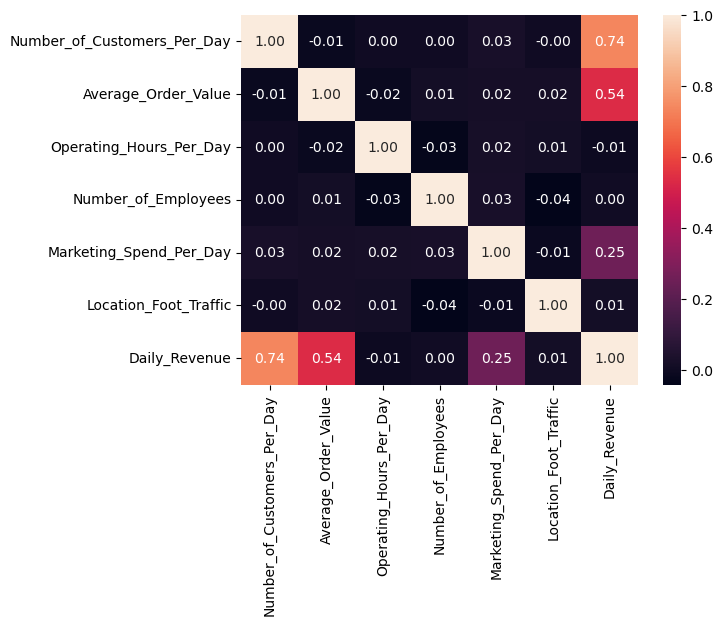

In [343]:
sns.heatmap(df.corr(), annot=True, fmt=".2f")

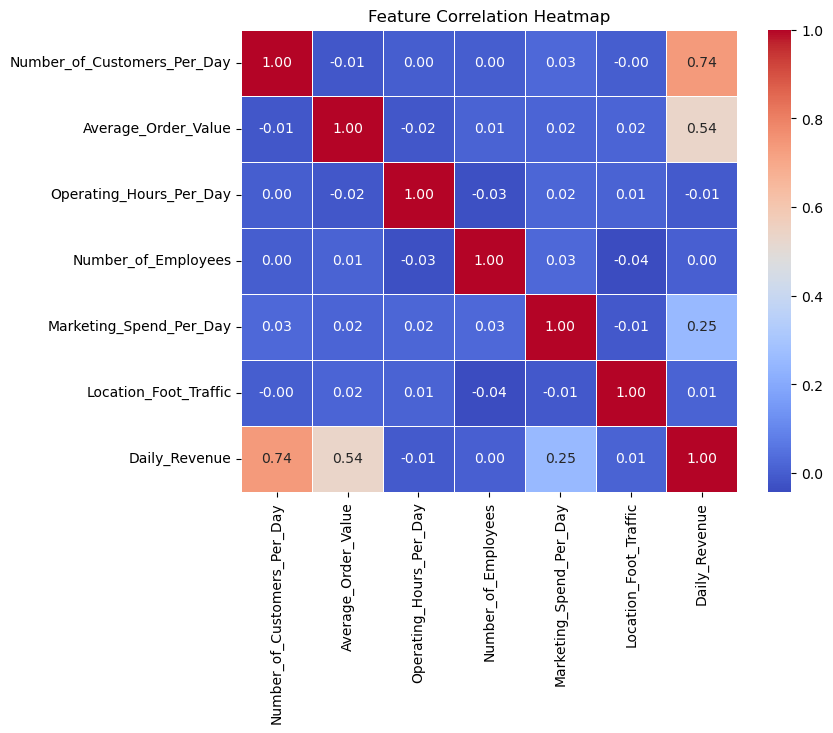

In [344]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

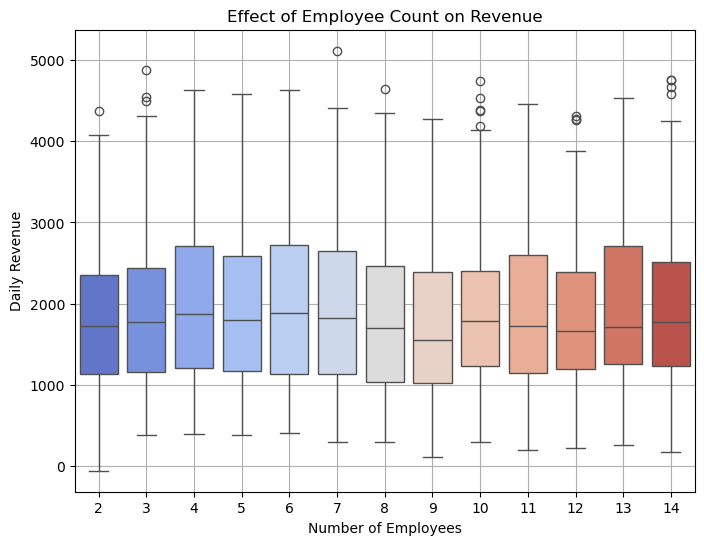

In [345]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=df["Number_of_Employees"], y=df["Daily_Revenue"], palette="coolwarm")
plt.xlabel("Number of Employees")
plt.ylabel("Daily Revenue")
plt.title("Effect of Employee Count on Revenue")
plt.grid(True)
plt.show()

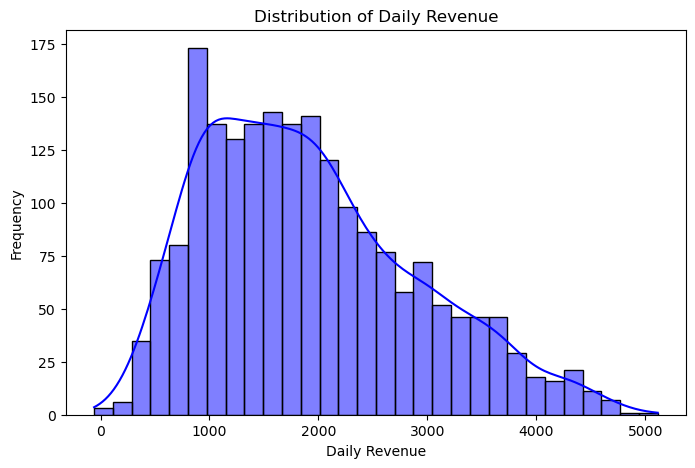

In [346]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Daily_Revenue"], bins=30, kde=True, color="blue")
plt.title("Distribution of Daily Revenue")
plt.xlabel("Daily Revenue")
plt.ylabel("Frequency")
plt.show()

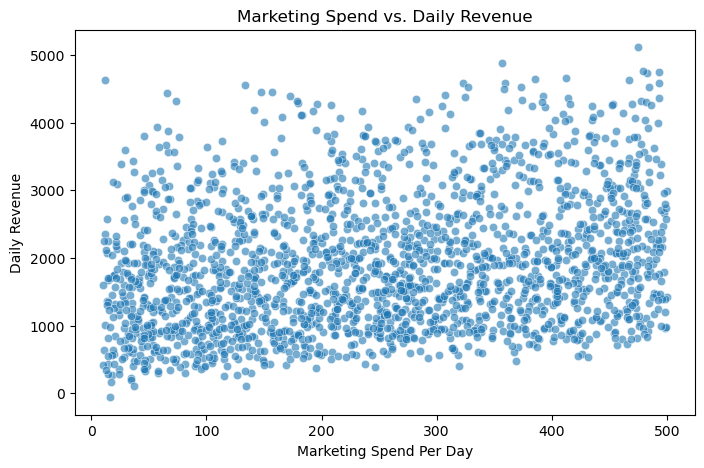

In [347]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df["Marketing_Spend_Per_Day"], y=df["Daily_Revenue"], alpha=0.6)
plt.title("Marketing Spend vs. Daily Revenue")
plt.xlabel("Marketing Spend Per Day")
plt.ylabel("Daily Revenue")
plt.show()

### **Step 4: Model Building**

In [349]:
X = df.drop('Daily_Revenue', axis=1)  
y = df['Daily_Revenue']  

In [350]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [351]:
print(f"Training features: {X_train.shape}")
print(f"Testing features: {X_test.shape}")
print(f"Training target: {y_train.shape}")
print(f"Testing target: {y_test.shape}")

Training features: (1600, 6)
Testing features: (400, 6)
Training target: (1600,)
Testing target: (400,)


In [352]:
mi_scores = mutual_info_regression(X_train, y_train)
mi_df = pd.DataFrame({'Feature': X_train.columns, 'MI Score': mi_scores})
mi_df = mi_df.sort_values(by='MI Score', ascending=False)
print(mi_df)

                       Feature  MI Score
0  Number_of_Customers_Per_Day  0.435959
1          Average_Order_Value  0.235516
4      Marketing_Spend_Per_Day  0.018825
2      Operating_Hours_Per_Day  0.008850
5        Location_Foot_Traffic  0.001283
3          Number_of_Employees  0.000000


In [353]:
train_df = pd.concat([X_train, y_train], axis=1)
corr_matrix = train_df.corr()
corr_matrix

,Number_of_Customers_Per_Day,Average_Order_Value,Operating_Hours_Per_Day,Number_of_Employees,Marketing_Spend_Per_Day,Location_Foot_Traffic,Daily_Revenue
Number_of_Customers_Per_Day,1.000000,-0.018574,-0.019574,-0.016624,0.016166,-0.008610,0.731764
Average_Order_Value,-0.018574,1.000000,-0.017148,0.001918,0.032235,0.057051,0.538643
Operating_Hours_Per_Day,-0.019574,-0.017148,1.000000,-0.025142,0.007824,0.024127,-0.020817
Number_of_Employees,-0.016624,0.001918,-0.025142,1.000000,0.026617,-0.041843,-0.012224
Marketing_Spend_Per_Day,0.016166,0.032235,0.007824,0.026617,1.000000,-0.000483,0.253093
Location_Foot_Traffic,-0.008610,0.057051,0.024127,-0.041843,-0.000483,1.000000,0.029800
Daily_Revenue,0.731764,0.538643,-0.020817,-0.012224,0.253093,0.029800,1.000000


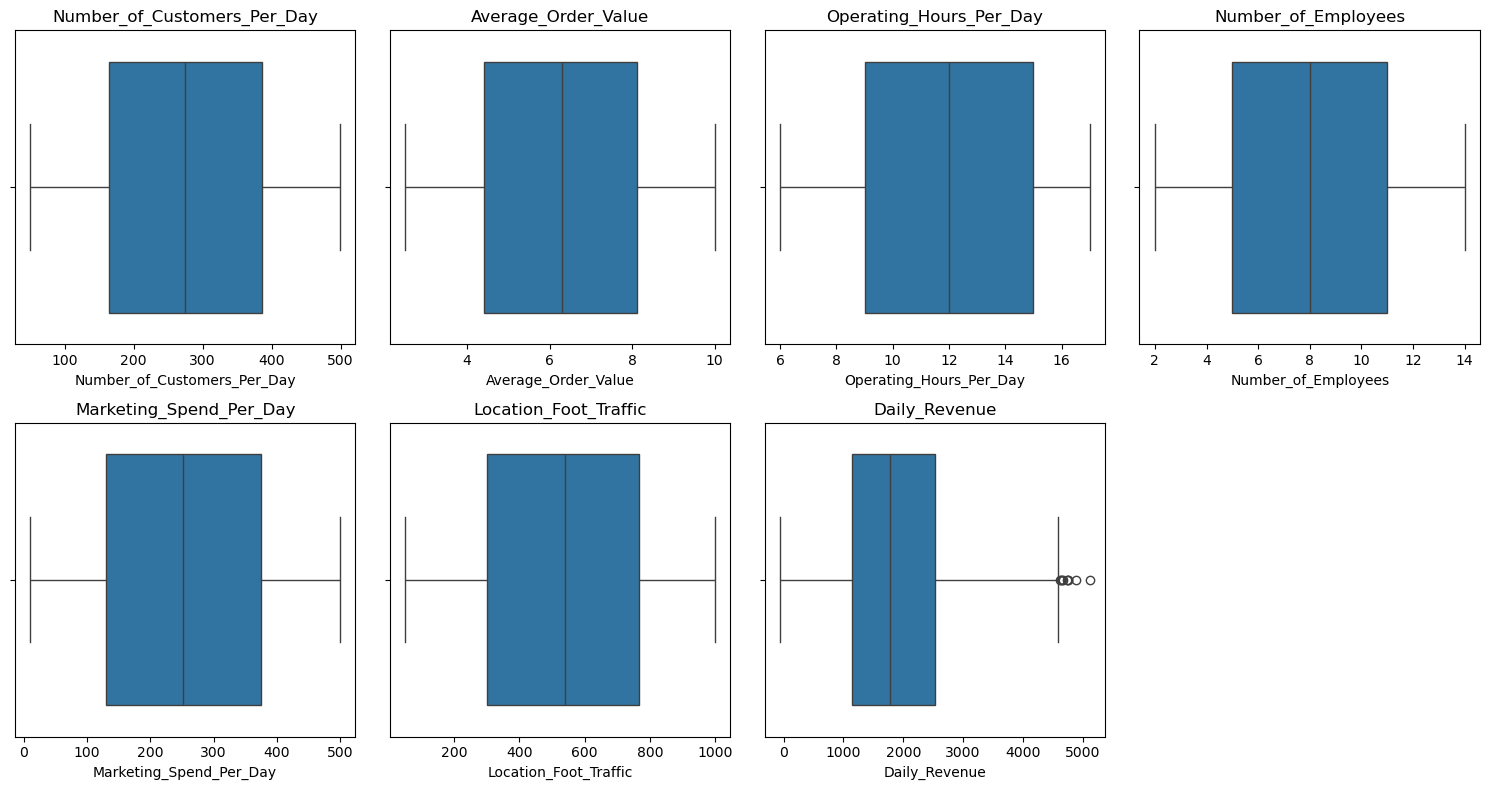

In [354]:
numeric_cols = df.columns
plt.figure(figsize=(15, 8))
for i, col in enumerate(numeric_cols):
    plt.subplot(2, (len(numeric_cols) + 1) // 2, i+1)
    sns.boxplot(x=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

#### **Train-Test-split**

In [356]:
X_train = X_train[['Number_of_Customers_Per_Day', 'Average_Order_Value', 'Marketing_Spend_Per_Day']]
X_test = X_test[['Number_of_Customers_Per_Day', 'Average_Order_Value', 'Marketing_Spend_Per_Day']]

In [357]:
model = RandomForestRegressor(random_state=42)
model.fit(X_train,y_train)

RandomForestRegressor(random_state=42)

In [358]:
Y_pred = model.predict(X_test)

In [359]:
mse = mean_squared_error(y_test, Y_pred)
print(f"Mean Squared Error: {mse}")

r2 = r2_score(y_test, Y_pred)
print(f"R-squared: {r2}")

Mean Squared Error: 47925.27316571808
R-squared: 0.9487083874161395


In [360]:
scores = cross_val_score(model, X, y, scoring='r2', cv=5)
print(f"Cross-Validation R²: {scores.mean()}")

Cross-Validation R²: 0.9457313869263835


### **Step 5 : Model Evaluation**

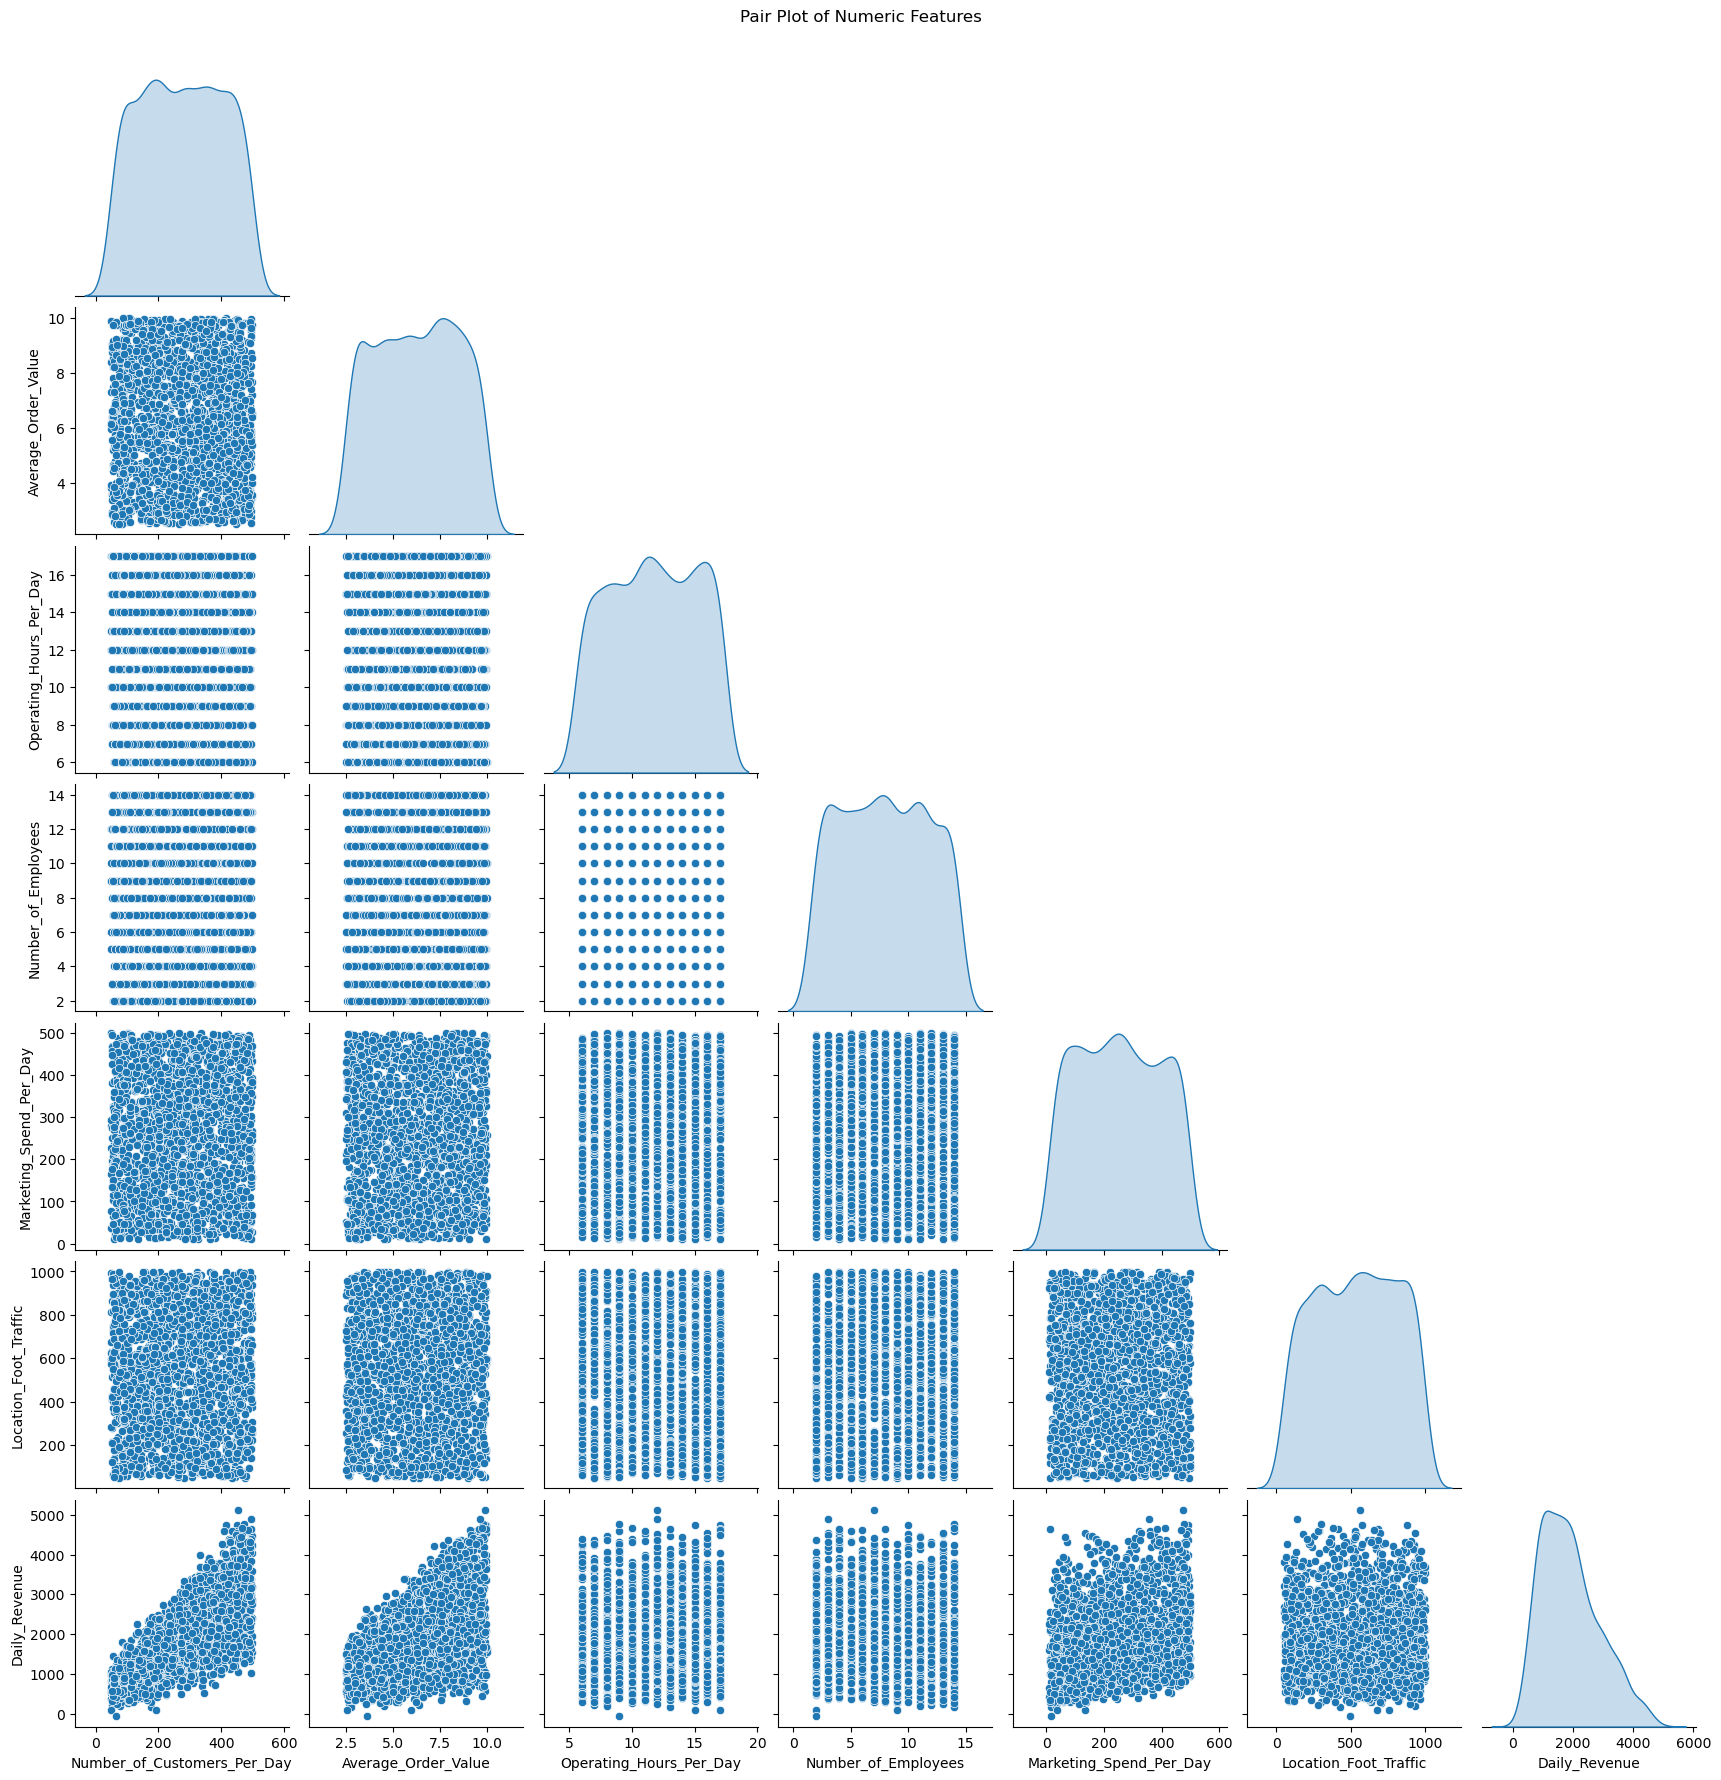

In [362]:
sns.pairplot(df, diag_kind='kde', corner=True)
plt.suptitle('Pair Plot of Numeric Features', y=1.02)
plt.show()

In [363]:
new_data = [[300,550,900]]  # Provide 3 values inside the list
predicted_revenue = model.predict(new_data)
print("Predicted Revenue:", predicted_revenue[0])

Predicted Revenue: 3119.1527000000015


In [364]:
avg_order_value = X_train["Average_Order_Value"].mean()
avg_marketing_spend = X_train["Marketing_Spend_Per_Day"].mean()

new_data = pd.DataFrame({
    "Number_of_Customers_Per_Day": [300],
    "Average_Order_Value": [avg_order_value],
    "Marketing_Spend_Per_Day": [avg_marketing_spend]
})

predicted_revenue = model.predict(new_data)
print("Predicted Revenue:", predicted_revenue[0])



Predicted Revenue: 1926.4470999999996


In [365]:
customer_range = np.arange(100, 1000, 10) 
avg_order_value = X_train["Average_Order_Value"].mean()
avg_marketing_spend = X_train["Marketing_Spend_Per_Day"].mean()

predict_data = pd.DataFrame({
    "Number_of_Customers_Per_Day": customer_range,
    "Average_Order_Value": [avg_order_value] * len(customer_range),
    "Marketing_Spend_Per_Day": [avg_marketing_spend] * len(customer_range)
})
predicted_revenues = model.predict(predict_data)
closest_index = np.abs(predicted_revenues - 5000).argmin()
required_customers = customer_range[closest_index]
print(f"Required Customers per Day to achieve ${5000} revenue:", required_customers)

Required Customers per Day to achieve $5000 revenue: 470


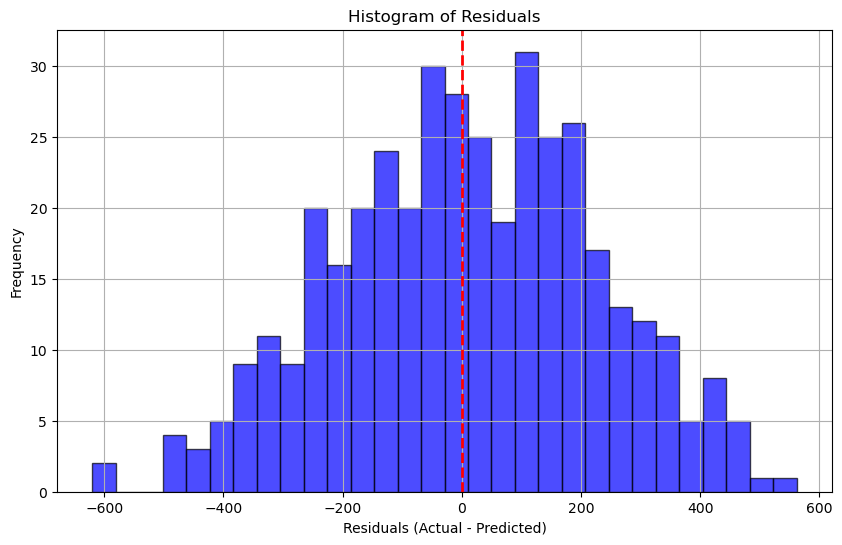

In [366]:
## Create a histogram of residuals - 

residuals = y_test - Y_pred

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=30, color='blue', edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.title('Histogram of Residuals')
plt.grid(True)
plt.show()

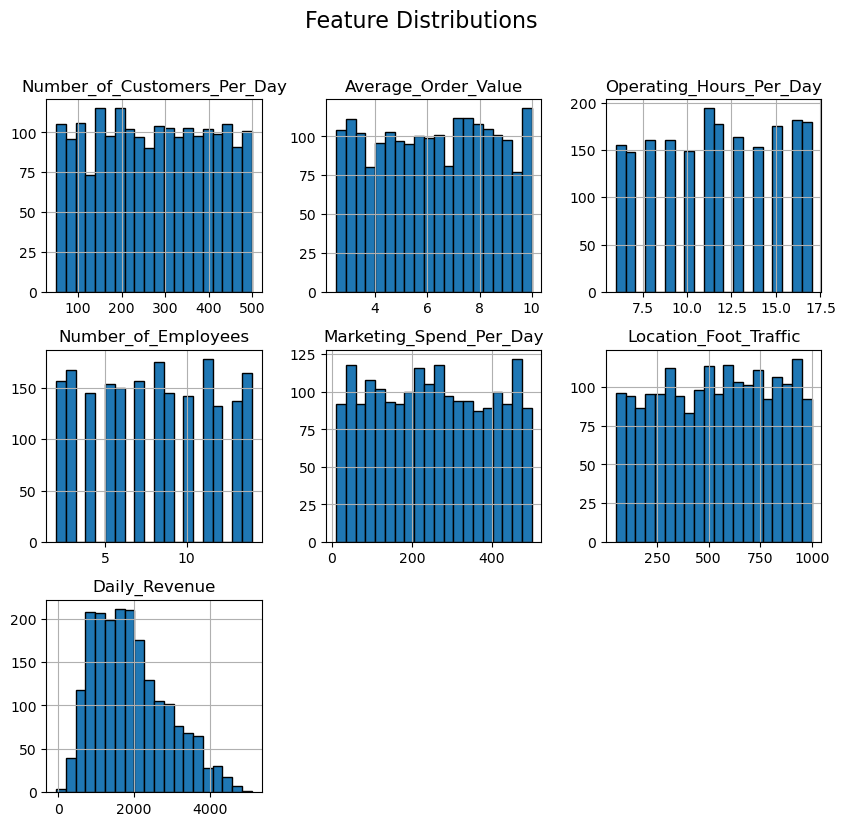

In [367]:
df.hist(figsize=(10, 9), bins=20, edgecolor='black')
plt.suptitle('Feature Distributions', fontsize=16)
plt.show()